# Model Explainability using SHAP

Modern credit risk models should not only predict accurately but also provide transparent explanations for their decisions.

This notebook explains the predictions of the final XGBoost model using SHAP (SHapley Additive exPlanations).

The objectives are:

- Identify the most influential risk factors globally
- Explain individual customer predictions
- Improve transparency for credit decision-making
- Support ethical and interpretable AI

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [3]:
!pip install shap

In [4]:
import shap

shap.initjs()

In [5]:
feature_path = "/content/drive/MyDrive/Credit_Risk_Project/data/behavioral_features.csv"

df = pd.read_csv(feature_path)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,default,pay_delay_trend,pay_delay_volatility,pay_trend,recency_weighted_stress,bill_payment_ratio,avg_utilization
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,1,0.914286,1.861899,4,4.5,11.084892,0.064200
1,2,120000,2,2,2,26,-1,2,0,0,...,1000,0,2000,1,-0.257143,1.224745,-3,4.0,3.411306,0.023718
2,3,90000,2,2,2,34,0,0,0,0,...,1000,1000,5000,0,0.000000,0.000000,0,0.0,9.221063,0.188246
3,4,50000,2,2,1,37,0,0,0,0,...,1100,1069,1000,0,0.000000,0.000000,0,0.0,27.559447,0.771113
4,5,50000,1,2,1,57,-1,0,-1,0,...,9000,689,679,0,-0.171429,0.516398,-1,-6.5,1.851477,0.364463


In [6]:
target = "default"

features = [
    col for col in df.columns
    if col not in ["ID", target]
]

X = df[features]
y = df[target]

In [7]:
model = joblib.load(
    "/content/drive/MyDrive/Credit_Risk_Project/models/xgboost.pkl"
)

In [8]:
print("="*70)
print("Production Explainability")
print("="*70)
print("Model :", type(model).__name__)
print("Customers :", len(df))
print("Features :", len(features))
print("="*70)

Production Explainability
Model : CalibratedClassifierCV
Customers : 30000
Features : 29


## Global Feature Importance

SHAP computes the contribution of every feature toward model predictions.

Higher absolute SHAP values indicate stronger influence on predicted default risk.

In [10]:
from sklearn.calibration import CalibratedClassifierCV

# If model is calibrated, extract the underlying XGBoost model
if isinstance(model, CalibratedClassifierCV):
    xgb_model = model.calibrated_classifiers_[0].estimator
else:
    xgb_model = model

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X)

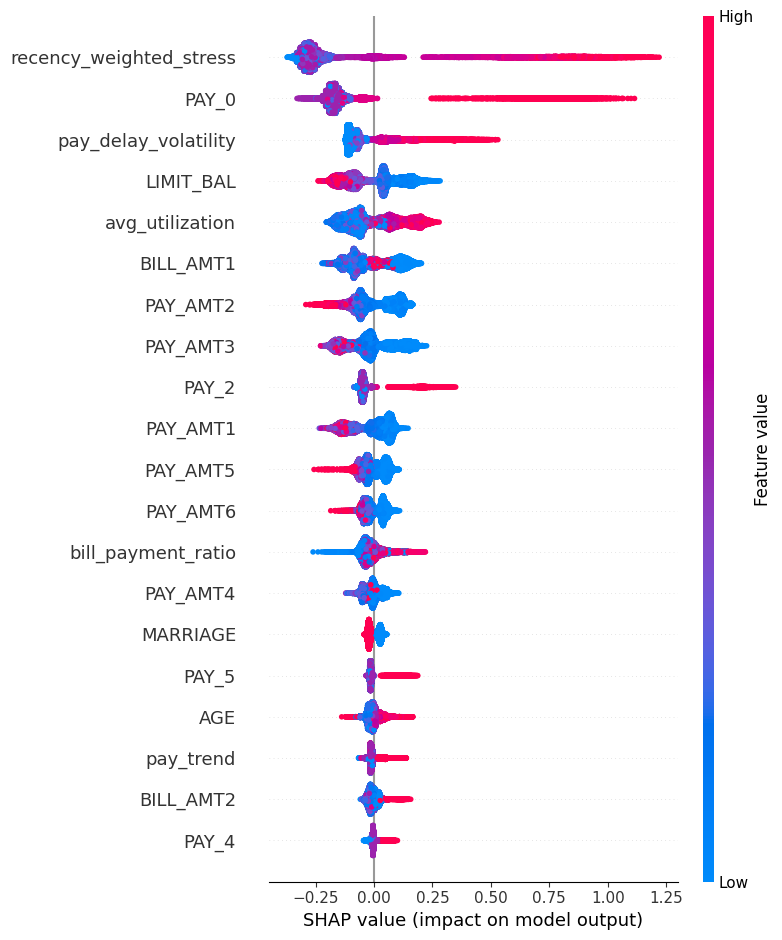

In [11]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X,
    show=False
)

plt.tight_layout()
plt.show()

Interpretation

Features appearing near the top of the plot contribute most strongly to predicted credit risk.

Red points indicate larger feature values.

Blue points indicate smaller feature values.

Horizontal spread reflects the magnitude of impact on prediction.

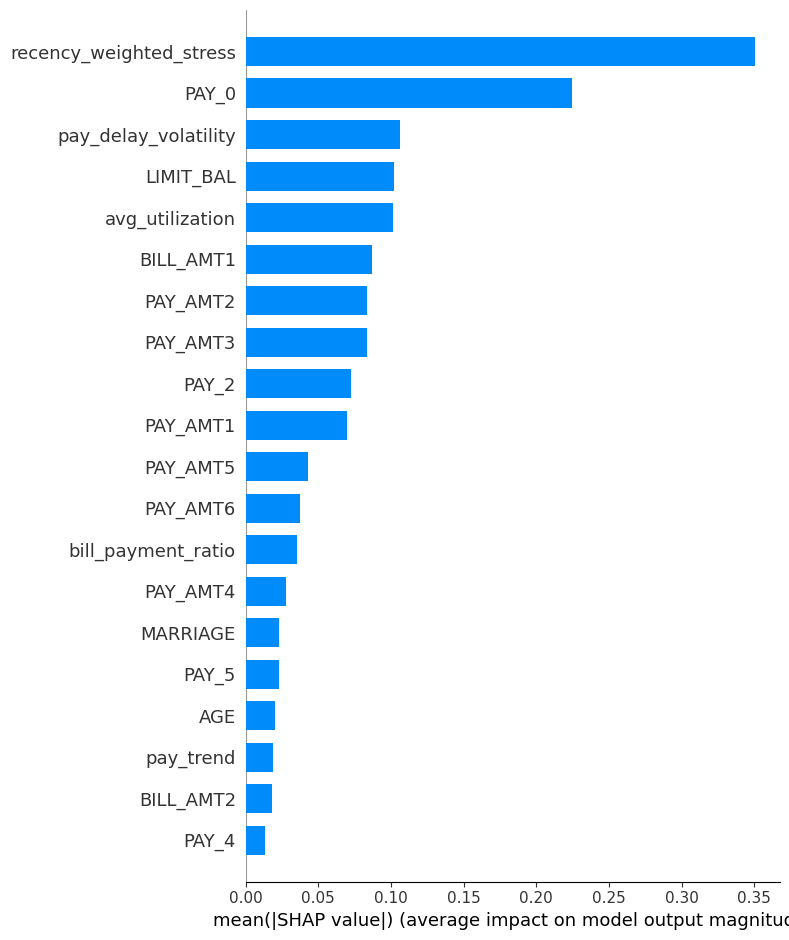

In [12]:
plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

The bar chart summarizes the average absolute contribution of each feature across all customers.

These represent the primary drivers of financial stress identified by the model.

## Explaining an Individual Customer

SHAP can explain why a specific customer receives a high predicted probability of default.

This improves transparency and helps credit analysts understand model decisions.

In [13]:
predictions = model.predict_proba(X)[:,1]

highest_risk = np.argmax(predictions)

highest_risk

np.int64(28851)

In [14]:
print("Predicted Default Probability:")

print(round(predictions[highest_risk],3))

Predicted Default Probability:
0.879


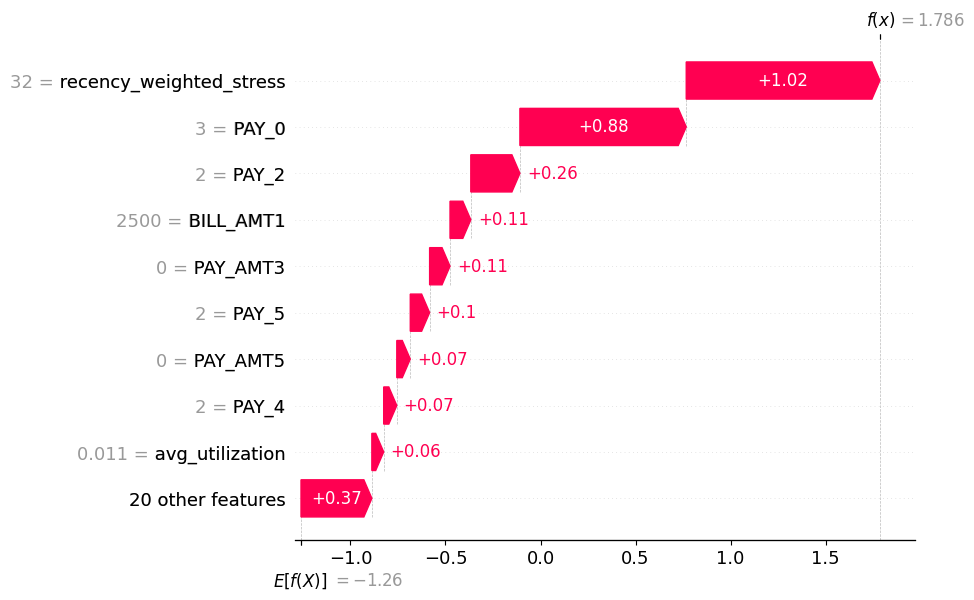

In [15]:
explanation = explainer(X.iloc[[highest_risk]])

shap.plots.waterfall(explanation[0])

Interpretation

The waterfall plot decomposes the predicted probability into individual feature contributions.

Positive SHAP values push the prediction toward default.

Negative SHAP values reduce estimated default risk.

This provides a transparent explanation for each prediction.

## Feature Interaction Analysis

Dependence plots illustrate how changes in a feature affect predicted credit risk.

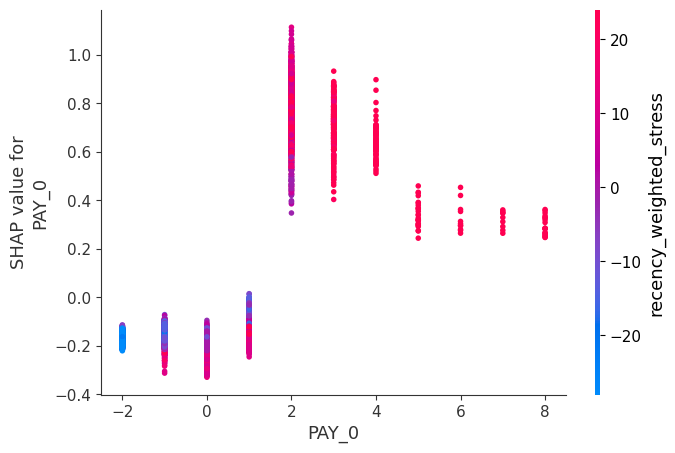

In [16]:
shap.dependence_plot(
    "PAY_0",
    shap_values,
    X
)

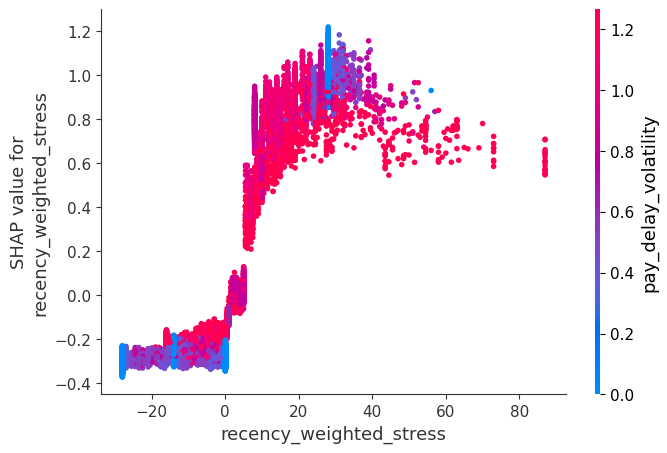

In [17]:
shap.dependence_plot(
    "recency_weighted_stress",
    shap_values,
    X
)

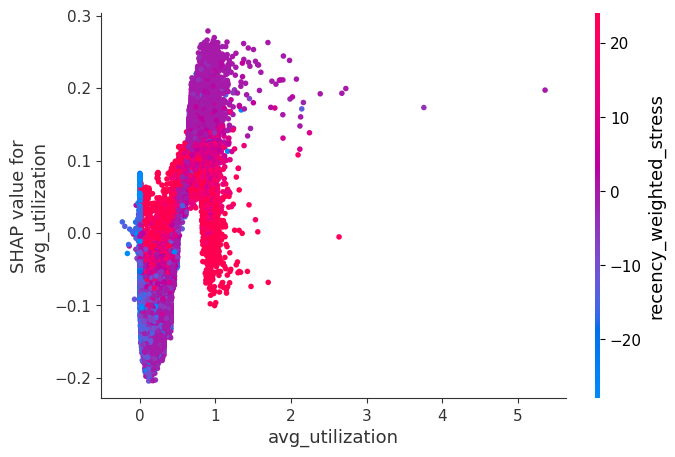

In [18]:
shap.dependence_plot(
    "avg_utilization",
    shap_values,
    X
)

In [19]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Mean |SHAP|": np.abs(shap_values).mean(axis=0)

})

importance = importance.sort_values(
    "Mean |SHAP|",
    ascending=False
)

importance.to_csv(
    "/content/drive/MyDrive/Credit_Risk_Project/explainability/shap_global_importance.csv",
    index=False
)

display(importance.head(15))

,Feature,Mean |SHAP|
26,recency_weighted_stress,0.350225
5,PAY_0,0.224737
24,pay_delay_volatility,0.106231
0,LIMIT_BAL,0.101728
28,avg_utilization,0.101539
11,BILL_AMT1,0.087230
18,PAY_AMT2,0.083631
19,PAY_AMT3,0.083208
6,PAY_2,0.072495
17,PAY_AMT1,0.069483


In [20]:
highest_risk = np.argmax(predictions)

In [21]:
top5 = np.argsort(predictions)[-5:][::-1]

print("Top 5 highest-risk customers")

display(

    pd.DataFrame({

        "Customer Index": top5,

        "Predicted Probability": predictions[top5]

    })

)

Top 5 highest-risk customers


,Customer Index,Predicted Probability
0,28851,0.878993
1,7788,0.878945
2,24345,0.878901
3,26801,0.878495
4,1956,0.877821


In [22]:
shap.plots.force(
    explanation[0]
)

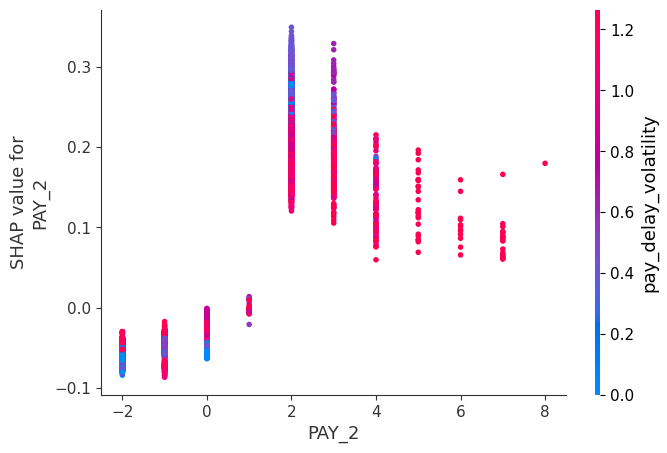

In [23]:
shap.dependence_plot(
    "PAY_2",
    shap_values,
    X
)

In [24]:
local = pd.DataFrame({

    "Feature": X.columns,

    "Value": X.iloc[highest_risk],

    "SHAP": explanation.values[0]

})

local["ABS"] = np.abs(local["SHAP"])

display(

    local.sort_values(

        "ABS",

        ascending=False

    ).head(10)

)

,Feature,Value,SHAP,ABS
recency_weighted_stress,recency_weighted_stress,32.000000,1.019134,1.019134
PAY_0,PAY_0,3.000000,0.875277,0.875277
PAY_2,PAY_2,2.000000,0.258332,0.258332
BILL_AMT1,BILL_AMT1,2500.000000,0.109372,0.109372
PAY_AMT3,PAY_AMT3,0.000000,0.107375,0.107375
PAY_5,PAY_5,2.000000,0.101802,0.101802
PAY_AMT5,PAY_AMT5,0.000000,0.070911,0.070911
PAY_4,PAY_4,2.000000,0.068987,0.068987
avg_utilization,avg_utilization,0.011364,0.062249,0.062249
EDUCATION,EDUCATION,1.000000,0.060738,0.060738


In [27]:
from sklearn.calibration import CalibratedClassifierCV

if isinstance(model, CalibratedClassifierCV):
    xgb_model = model.calibrated_classifiers_[0].estimator
else:
    xgb_model = model

comparison = pd.DataFrame({
    "XGBoost Importance": xgb_model.feature_importances_,
    "Mean |SHAP|": np.abs(shap_values).mean(axis=0)
}, index=X.columns)

comparison = comparison.sort_values(
    "Mean |SHAP|",
    ascending=False
)

display(comparison.head(15))

,XGBoost Importance,Mean |SHAP|
recency_weighted_stress,0.171100,0.350225
PAY_0,0.167525,0.224737
pay_delay_volatility,0.051287,0.106231
LIMIT_BAL,0.016060,0.101728
avg_utilization,0.014266,0.101539
BILL_AMT1,0.012866,0.087230
PAY_AMT2,0.021535,0.083631
PAY_AMT3,0.018738,0.083208
PAY_2,0.233932,0.072495
PAY_AMT1,0.014763,0.069483


SHAP confirms that the production XGBoost model relies predominantly on repayment behaviour and financial stress indicators rather than demographic variables. Features such as PAY_0, recency-weighted stress, average utilization, payment delay volatility, and recent billing behaviour consistently exhibit the highest SHAP contributions, demonstrating that the model bases its predictions on meaningful behavioural signals rather than sensitive customer attributes.

SHAP summary figure saved.


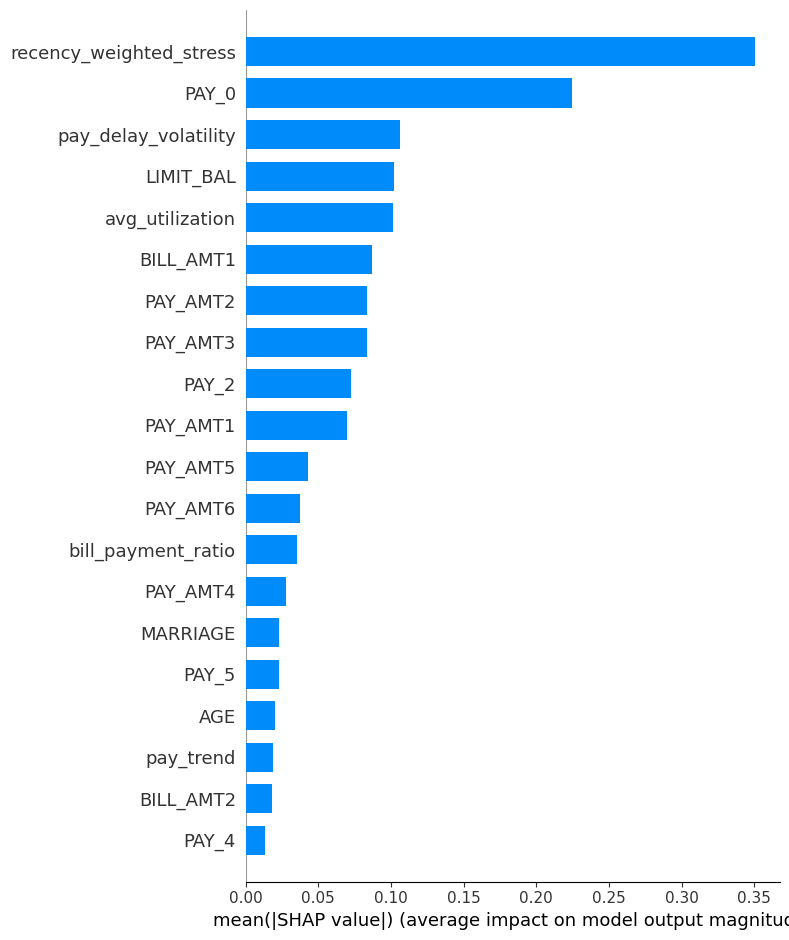

In [28]:
import os

os.makedirs(
    "/content/drive/MyDrive/Credit_Risk_Project/explainability",
    exist_ok=True
)

plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Credit_Risk_Project/explainability/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

print("SHAP summary figure saved.")

# Conclusion

SHAP complements traditional feature importance by providing both global and local explanations for model predictions.

Unlike standard importance measures, SHAP quantifies how each feature contributes to the predicted probability for every individual customer.

The explainability framework demonstrates that behavioral indicators such as repayment trends, financial stress, and utilization consistently drive model predictions, supporting the project's objective of detecting financial stress before default occurs.

This notebook enhances the transparency, interpretability, and practical applicability of the credit risk scoring system.